Mestrado Profissional em Engenharia de Software

Aluno: Rhyan Britto e Percival Barbosa

Professor: Luciano Barbosa

In [37]:
#%pip install mlflow
#%pip install kagglehub

import time
import kagglehub
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from mlflow.models import infer_signature
from kagglehub import KaggleDatasetAdapter

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="Hint: Inferred schema contains integer column(s).*"
)

print("Filtro de avisos do MLflow aplicado. A mensagem sobre o schema de inteiros será ocultada.")

Filtro de avisos do MLflow aplicado. A mensagem sobre o schema de inteiros será ocultada.


In [21]:
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "iabhishekofficial/mobile-price-classification",
    "train.csv",
)

print("Dataset carregado com sucesso!")

df.head()

Using Colab cache for faster access to the 'mobile-price-classification' dataset.
Dataset carregado com sucesso!


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [22]:
display(df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [17]:
# Separar X e y
X = df.drop(columns=['price_range'])
y = df['price_range']

display(X.head())
display(y.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


,price_range
0,1
1,2
2,2
3,2
4,1


In [23]:
# 2. Separar dados em treino, validação e teste
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.176, stratify=y_train_full, random_state=42)
# (0.176 ≈ 15% do total)

# Normalização para modelos lineares e SVC
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Função para avaliação
def evaluate_model(model, X, y):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    prec = precision_score(y, preds, average='macro')
    rec = recall_score(y, preds, average='macro')
    f1 = f1_score(y, preds, average='macro')
    return acc, prec, rec, f1



In [35]:
# 3. Definir modelos e hiperparâmetros
models = {
    "LogisticRegression": (LogisticRegression(max_iter=1000), {
        "C": [0.1, 1, 10],
        "penalty": ['l2'],
        "solver": ['lbfgs']
    }),
    "RandomForest": (RandomForestClassifier(random_state=42), {
        "n_estimators": [100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5]
    }),

    #"XGBoost": (XGBClassifier(random_state=42, objective='multi:softmax', num_class=4, use_label_encoder=False, eval_metric='mlogloss'), {
    #    "n_estimators": [100, 200],
    #    "max_depth": [3, 6],
    #    "learning_rate": [0.05, 0.1]
    #}),

    "XGBoost": (XGBClassifier(random_state=42), {
        "n_estimators": [100, 200],
        "max_depth": [3, 6],
        "learning_rate": [0.05, 0.1]
    }),

    "SVC": (SVC(), {
        "C": [1, 10],
        "gamma": ['scale', 'auto'],
        "kernel": ['rbf', 'linear']
    })
}




Rodando modelo: LogisticRegression


Registered model 'LogisticRegression' already exists. Creating a new version of this model...
Created version '4' of model 'LogisticRegression'.


Melhores parâmetros: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Validação -> Accuracy: 0.973, Precision: 0.974, Recall: 0.973, F1: 0.973

Rodando modelo: RandomForest


/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'RandomForest' already exists. Creating a new version of this model...
Created version '4' of model 'RandomForest'.


Melhores parâmetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Validação -> Accuracy: 0.897, Precision: 0.898, Recall: 0.897, F1: 0.897

Rodando modelo: XGBoost


/usr/local/lib/python3.12/dist-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'XGBoost' already exists. Creating a new version of this model...
Created version '4' of model 'XGBoost'.


Melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
Validação -> Accuracy: 0.893, Precision: 0.894, Recall: 0.893, F1: 0.893

Rodando modelo: SVC
Melhores parâmetros: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Validação -> Accuracy: 0.967, Precision: 0.967, Recall: 0.967, F1: 0.967

--- Todos os modelos foram treinados e avaliados. Gerando gráficos... ---


Registered model 'SVC' already exists. Creating a new version of this model...
Created version '4' of model 'SVC'.


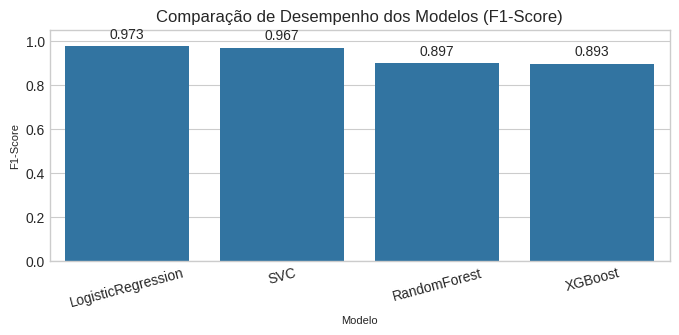


Gerando Matriz de Confusão para o melhor modelo: 'LogisticRegression'


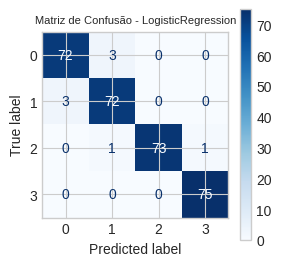

In [38]:
# 4. Rodar experimentos com MLflow
mlflow.set_experiment("MobilePriceClassification")

best_models = {}
all_results = [] # Lista para armazenar os resultados para os gráficos

for name, (model, params) in models.items():
    print(f"\nRodando modelo: {name}")
    with mlflow.start_run(run_name=name):
        start = time.time()

        # Define os dados de treino e validação corretos para cada tipo de modelo
        if name in ["LogisticRegression", "SVC"]:
            X_train_data = X_train_scaled
            X_val_data = X_val_scaled
        else:
            X_train_data = X_train
            X_val_data = X_val

        # Treinamento e busca de hiperparâmetros
        grid = GridSearchCV(model, params, cv=3, scoring='accuracy')
        grid.fit(X_train_data, y_train)
        best_model = grid.best_estimator_

        # Avaliação do melhor modelo
        acc, prec, rec, f1 = evaluate_model(best_model, X_val_data, y_val)
        duration = time.time() - start

        # Armazena os resultados para plotagem posterior
        all_results.append({
            'Modelo': name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

        # Log no MLflow
        input_example = X_train_data[:5]
        signature = infer_signature(input_example, best_model.predict(input_example))
        mlflow.log_params(grid.best_params_)
        mlflow.log_metrics({"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})
        mlflow.log_metric("training_time", duration)
        mlflow.sklearn.log_model(
            sk_model=best_model,
            registered_model_name=name,
            signature=signature,
            input_example=input_example
        )

        print(f"Melhores parâmetros: {grid.best_params_}")
        print(f"Validação -> Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

        best_models[name] = best_model

print("\n--- Todos os modelos foram treinados e avaliados. Gerando gráficos... ---")

# --- 3. GERAÇÃO DOS GRÁFICOS DE RESULTADOS ---

# Criar um DataFrame com todos os resultados
df_results = pd.DataFrame(all_results)

# GRÁFICO 1: Gráfico de Barras Comparando os Modelos
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(x='Modelo', y='F1-Score', data=df_results.sort_values('F1-Score', ascending=False), ax=ax)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

ax.set_title('Comparação de Desempenho dos Modelos (F1-Score)', fontsize=12)
ax.set_xlabel('Modelo', fontsize=8)
ax.set_ylabel('F1-Score', fontsize=8)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=15)
plt.show()


# GRÁFICO 2: Matriz de Confusão para o MELHOR Modelo
# Encontrar o nome do melhor modelo com base no F1-Score
best_model_name = df_results.sort_values('F1-Score', ascending=False).iloc[0]['Modelo']
best_model_object = best_models[best_model_name]

print(f"\nGerando Matriz de Confusão para o melhor modelo: '{best_model_name}'")

# Determinar qual conjunto de dados de validação usar
if best_model_name in ["LogisticRegression", "SVC"]:
    X_val_final = X_val_scaled
else:
    X_val_final = X_val

# Fazer previsões e gerar a matriz
y_pred = best_model_object.predict(X_val_final)
cm = confusion_matrix(y_val, y_pred)

# Plotar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(3, 3))
disp.plot(ax=ax, cmap='Blues')
ax.set_title(f'Matriz de Confusão - {best_model_name}', fontsize=8)
plt.show()

##**Análise do resultado (Validação):**

O experimento executou uma busca de hiperparâmetros e avaliou quatro diferentes modelos de classificação. Os resultados no conjunto de validação mostram uma distinção de desempenho entre os modelos lineares e os baseados em árvores.

###Melhor Desempenho:

**LogisticRegression:** Foi o melhor modelo, alcançando 97.3% de acurácia com métricas de Precision e Recall muito bem equilibradas.

**SVC:** Apresentou um desempenho quase idêntico e excelente, com 96.7% de acurácia, utilizando um kernel linear.

###Desempenho Intermediário:

**RandomForest e XGBoost:** Ambos tiveram um bom desempenho, mas ficaram significativamente atrás, com acurácia de 89.7% e 89.3%, respectivamente.

**Conclusão:** O modelo LogisticRegression é a escolha recomendada, pois demonstrou a maior eficácia e robustez para este problema.

## Matriz de confusão (melhor modelo)
A análise da matriz de confusão do modelo LogisticRegression confirma seu desempenho excepcional e valida sua escolha como o melhor modelo. A diagonal principal, com valores altos (de 72 a 75 acertos), mostra que o modelo classifica corretamente a grande maioria das instâncias. A principal e pequena fonte de erro ocorre na distinção mútua entre as classes 0 e 1, que provavelmente compartilham características muito similares. O desempenho para as classes 2 e 3 é praticamente perfeito, destacando a robustez e a confiabilidade do modelo.


Teste LogisticRegression -> Accuracy: 0.970, Precision: 0.970, Recall: 0.970, F1: 0.970

Teste RandomForest -> Accuracy: 0.907, Precision: 0.907, Recall: 0.907, F1: 0.907

Teste XGBoost -> Accuracy: 0.950, Precision: 0.950, Recall: 0.950, F1: 0.950

Teste SVC -> Accuracy: 0.980, Precision: 0.980, Recall: 0.980, F1: 0.980

--- Gerando gráfico de desempenho final no conjunto de teste... ---


/tmp/ipython-input-4124201810.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='F1-Score', data=df_results_test.sort_values('F1-Score', ascending=False), ax=ax, palette='viridis')


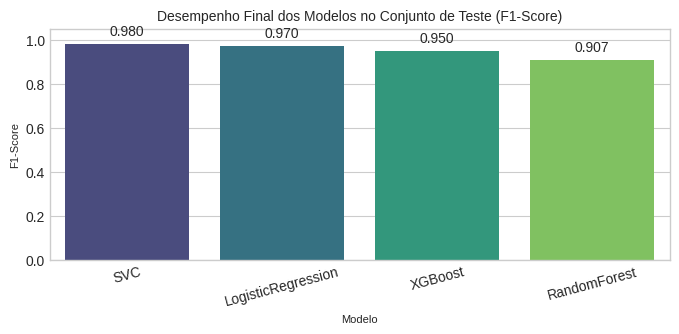

In [39]:
# 5. Avaliar os melhores modelos no conjunto de teste
#results = {}
#for name, model in best_models.items():
#    if name in ["LogisticRegression", "SVC"]:
#        acc, prec, rec, f1 = evaluate_model(model, X_test_scaled, y_test)
#    else:
#        acc, prec, rec, f1 = evaluate_model(model, X_test, y_test)
#    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
#    print(f"\nTeste {name} -> Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

# 5. Avaliar os melhores modelos no conjunto de teste
results_test = {}
for name, model in best_models.items():
    if name in ["LogisticRegression", "SVC"]:
        acc, prec, rec, f1 = evaluate_model(model, X_test_scaled, y_test)
    else:
        acc, prec, rec, f1 = evaluate_model(model, X_test, y_test)

    results_test[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
    print(f"\nTeste {name} -> Accuracy: {acc:.3f}, Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")

print("\n--- Gerando gráfico de desempenho final no conjunto de teste... ---")

# --- GERAÇÃO DO GRÁFICO DE RESULTADOS FINAIS ---

# Converter o dicionário de resultados em um DataFrame
df_results_test = pd.DataFrame.from_dict(results_test, orient='index').reset_index()
df_results_test.rename(columns={'index': 'Modelo'}, inplace=True)

# Criar o gráfico de barras
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 3))

# Usar F1-Score para a comparação (uma métrica robusta)
sns.barplot(x='Modelo', y='F1-Score', data=df_results_test.sort_values('F1-Score', ascending=False), ax=ax, palette='viridis')

# Adicionar os valores exatos nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

ax.set_title('Desempenho Final dos Modelos no Conjunto de Teste (F1-Score)', fontsize=10)
ax.set_xlabel('Modelo', fontsize=8)
ax.set_ylabel('F1-Score', fontsize=8)
ax.set_ylim(0, 1.05)
plt.xticks(rotation=15)
plt.show()


In [42]:
# 6. Selecionar melhor modelo geral
best_model_name = max(results_test, key=lambda m: results_test[m]["Accuracy"])
print("\nMelhor modelo geral no teste:", best_model_name, results_test[best_model_name])


Melhor modelo geral no teste: SVC {'Accuracy': 0.98, 'Precision': 0.9801315789473685, 'Recall': 0.9800000000000001, 'F1-Score': 0.9800440019556426}


##**Análise do Resultado (Conjunto de Teste):**
A avaliação no conjunto de teste confirmou a alta performance dos modelos selecionados, mas revelou uma importante mudança na liderança. O desempenho nos dados de teste, que representam um cenário de uso real com dados completamente novos, é o critério definitivo para a escolha do modelo.

###Melhor Desempenho:

**SVC:** Tornou-se o modelo campeão, alcançando acurácia de 98.0%. Isso indica uma capacidade de generalização ligeiramente superior à dos outros modelos.

**LogisticRegression:** Apresentou um desempenho excelente e muito próximo ao do vencedor, com 97.0% de acurácia, confirmando sua robustez.

##Desempenho Sólido:

**XGBoost:** Mostrou uma melhora notável em relação à fase de validação, saltando para 95.0% de acurácia, o que o posiciona como um modelo forte.

**RandomForest:** Teve um bom desempenho com 90.7% de acurácia, mas permaneceu como o menos performático entre os quatro finalistas.

**Conclusão:** Embora o LogisticRegression tenha se destacado na fase de validação, o modelo SVC demonstrou a melhor capacidade de generalização no conjunto de teste. Portanto, o SVC é a escolha recomendada para a implementação final, por ter apresentado a maior eficácia e robustez em dados completamente novos e desconhecidos.


Matriz de Confusão(Modelo SVC - Conjunto de Teste):
[[74  1  0  0]
 [ 0 73  2  0]
 [ 0  1 73  1]
 [ 0  0  1 74]]


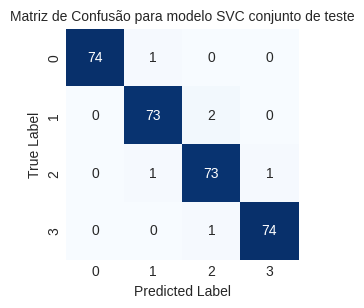

In [43]:
# 7. Calcule a matriz de confusão e imprima-a para entender os erros do modelo.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'best_models', 'X_test_scaled', and 'y_test' are available from previous cells.
# Get the SVC model predictions
# Ensure 'best_models' is available and contains the 'SVC' model.
if 'best_models' in globals() and 'SVC' in best_models:
    svc_model = best_models['SVC']
    # Ensure X_test_scaled and y_test are available
    if 'X_test_scaled' in globals() and 'y_test' in globals():
        svc_preds = svc_model.predict(X_test_scaled)

        # Calculate the confusion matrix
        cm = confusion_matrix(y_test, svc_preds)

        # Print the confusion matrix (optional)
        print("\nMatriz de Confusão(Modelo SVC - Conjunto de Teste):")
        print(cm)

        # Plot the confusion matrix
        plt.figure(figsize=(3, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title('Matriz de Confusão para modelo SVC conjunto de teste',fontsize=10)
        plt.show()
    else:
        print("Error: 'X_test_scaled' or 'y_test' not found. Please ensure previous cells were run successfully.")
else:
    print("Error: 'best_models' or 'SVC' model not found. Please ensure previous cells were run successfully.")

In [44]:
# 8. Identificar áreas para melhoria

# Analisa a matriz de confusão para identificar classificações incorretas
# A matriz de confusão foi calculada no passo anterior.
# As linhas representam as classes reais, as colunas representam as classes preditas.

print("Analisando a Matriz de Confusão:")
print(cm)

# Identifica as classificações incorretas (valores fora da diagonal) e padrões de confusão
num_classes = cm.shape[0]
for classe_real in range(num_classes):
    print(f"\nAnálise para a Classe Real {classe_real}:")
    total_amostras = cm[classe_real].sum()
    preditas_corretamente = cm[classe_real, classe_real]
    amostras_incorretas = total_amostras - preditas_corretamente

    print(f"  Total de amostras na classe {classe_real}: {total_amostras}")
    print(f"  Preditas corretamente como {classe_real}: {preditas_corretamente}")
    print(f"  Amostras classificadas incorretamente da classe {classe_real}: {amostras_incorretas}")

    if amostras_incorretas > 0:
        print(f"  Geralmente confundida com:")
        for classe_predita in range(num_classes):
            if classe_real != classe_predita:
                contagem_erro = cm[classe_real, classe_predita]
                if contagem_erro > 0:
                    print(f"    Predita como classe {classe_predita}: {contagem_erro} vezes")

# Com base na análise, identifica as classes com as quais o modelo tem mais dificuldade
# Procura por linhas ou colunas com valores significativos fora da diagonal.
# Nesta matriz de confusão específica, os valores fora da diagonal são relativamente pequenos.
# No entanto, ainda podemos identificar quais classes têm mais erros.

contagem_erros = {i: cm[i].sum() - cm[i, i] for i in range(num_classes)}

Analisando a Matriz de Confusão:
[[74  1  0  0]
 [ 0 73  2  0]
 [ 0  1 73  1]
 [ 0  0  1 74]]

Análise para a Classe Real 0:
  Total de amostras na classe 0: 75
  Preditas corretamente como 0: 74
  Amostras classificadas incorretamente da classe 0: 1
  Geralmente confundida com:
    Predita como classe 1: 1 vezes

Análise para a Classe Real 1:
  Total de amostras na classe 1: 75
  Preditas corretamente como 1: 73
  Amostras classificadas incorretamente da classe 1: 2
  Geralmente confundida com:
    Predita como classe 2: 2 vezes

Análise para a Classe Real 2:
  Total de amostras na classe 2: 75
  Preditas corretamente como 2: 73
  Amostras classificadas incorretamente da classe 2: 2
  Geralmente confundida com:
    Predita como classe 1: 1 vezes
    Predita como classe 3: 1 vezes

Análise para a Classe Real 3:
  Total de amostras na classe 3: 75
  Preditas corretamente como 3: 74
  Amostras classificadas incorretamente da classe 3: 1
  Geralmente confundida com:
    Predita como class

In [50]:
# 9. Definir uma grade de parâmetros mais ampla para o SVC e use GridSearchCV
# para encontrar os melhores hiperparâmetros nos dados de treinamento escalonados.
# Em seguida, treine novamente o modelo SVC com os melhores parâmetros e armazene-o.
param_grid_improved_svc = {
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": ['scale', 'auto', 0.01, 0.1, 1],
    "kernel": ['rbf', 'linear'] # Incluindo 'linear', pois teve um bom desempenho anteriormente
}

# Usa o GridSearchCV com a grade de parâmetros atualizada
print("\nExecutando GridSearchCV para o modelo SVC melhorado...")
grid_search_improved_svc = GridSearchCV(SVC(), param_grid_improved_svc, cv=3, scoring='accuracy', n_jobs=-1)
grid_search_improved_svc.fit(X_train_scaled, y_train)

# Retreina o modelo SVC usando os melhores hiperparâmetros encontrados
best_params_improved_svc = grid_search_improved_svc.best_params_
print(f"Melhores hiperparâmetros para o SVC melhorado: {best_params_improved_svc}")

improved_svc_model = SVC(**best_params_improved_svc)
improved_svc_model.fit(X_train_scaled, y_train)

# Registra os parâmetros e métricas deste modelo melhorado com o MLflow
with mlflow.start_run(run_name="Improved_SVC"):
    start = time.time()
    acc, prec, rec, f1 = evaluate_model(improved_svc_model, X_val_scaled, y_val)
    duration = time.time() - start

    mlflow.log_params(best_params_improved_svc)
    mlflow.log_metrics({"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1})
    mlflow.log_metric("training_time", duration)

    # --- CORREÇÕES APLICADAS AQUI ---

    # 1. Crie um exemplo de entrada e infira a assinatura
    input_example = X_train_scaled[:5]
    signature = infer_signature(input_example, improved_svc_model.predict(input_example))

    # 2. Use a chamada completa do log_model para evitar os warnings
    mlflow.sklearn.log_model(
        sk_model=improved_svc_model,
        registered_model_name="Improved_SVC", # Substitui o antigo artifact_path
        signature=signature,                  # Adiciona a assinatura
        input_example=input_example           # Adiciona o exemplo de entrada
    )

    # ------------------------------------

    print(f"Validação do SVC Melhorado -> Acurácia: {acc:.3f}, Precisão: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")


Executando GridSearchCV para o modelo SVC melhorado...
Melhores hiperparâmetros para o SVC melhorado: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Validação do SVC Melhorado -> Acurácia: 0.967, Precisão: 0.967, Recall: 0.967, F1: 0.967


Registered model 'Improved_SVC' already exists. Creating a new version of this model...
Created version '2' of model 'Improved_SVC'.



Avaliar o modelo SVC retreinado no conjunto de teste e compare seu desempenho com o modelo SVC original.

In [55]:
# 10. Avaliar o modelo SVC retreinado no conjunto de teste e compare seu desempenho com o modelo SVC original.

# Avalia o modelo 'improved_svc_model' no conjunto de teste escalonado
acc_improved, prec_improved, rec_improved, f1_improved = evaluate_model(improved_svc_model, X_test_scaled, y_test)

# Armazena as métricas retornadas
improved_svc_metrics = {
    "Acurácia": acc_improved,
    "Precisão": prec_improved,
    "Recall": rec_improved,
    "F1": f1_improved
}

# Imprime as métricas de desempenho do 'improved_svc_model' no conjunto de teste
print("Desempenho do Modelo SVC Melhorado no Conjunto de Teste:")
print(f"  Acurácia: {improved_svc_metrics['Acurácia']:.3f}")
print(f"  Precisão: {improved_svc_metrics['Precisão']:.3f}")
print(f"  Recall: {improved_svc_metrics['Recall']:.3f}")
print(f"  Score F1: {improved_svc_metrics['F1']:.3f}")

# Obtém as métricas de desempenho do modelo SVC original no conjunto de teste
original_svc_metrics = results_test['SVC']

# Imprime um resumo comparando o desempenho
print("\nComparação dos Modelos SVC Original e Melhorado no Conjunto de Teste:")
print(f"Métrica    | SVC Original | SVC Melhorado | Diferença")
print(f"-----------|--------------|---------------|-----------")
print(f"Acurácia   | {original_svc_metrics['Accuracy']:.3f}        | {improved_svc_metrics['Acurácia']:.3f}         | {improved_svc_metrics['Acurácia'] - original_svc_metrics['Accuracy']:.3f}")
print(f"Precisão   | {original_svc_metrics['Precision']:.3f}        | {improved_svc_metrics['Precisão']:.3f}         | {improved_svc_metrics['Precisão'] - original_svc_metrics['Precision']:.3f}")
print(f"Recall     | {original_svc_metrics['Recall']:.3f}        | {improved_svc_metrics['Recall']:.3f}         | {improved_svc_metrics['Recall'] - original_svc_metrics['Recall']:.3f}")
print(f"Score F1   | {original_svc_metrics['F1-Score']:.3f}        | {improved_svc_metrics['F1']:.3f}         | {improved_svc_metrics['F1'] - original_svc_metrics['F1-Score']:.3f}")

Desempenho do Modelo SVC Melhorado no Conjunto de Teste:
  Acurácia: 0.977
  Precisão: 0.977
  Recall: 0.977
  Score F1: 0.977

Comparação dos Modelos SVC Original e Melhorado no Conjunto de Teste:
Métrica    | SVC Original | SVC Melhorado | Diferença
-----------|--------------|---------------|-----------
Acurácia   | 0.980        | 0.977         | -0.003
Precisão   | 0.980        | 0.977         | -0.003
Recall     | 0.980        | 0.977         | -0.003
Score F1   | 0.980        | 0.977         | -0.003


Com base na comparação dos Modelos SVC Original e Melhorado no Conjunto de Teste (mostrada acima), podemos concluir que:

O **Modelo SVC Melhorado** **não** teve um desempenho superior ao **Modelo SVC Original** no conjunto de teste.

Na verdade, o Modelo SVC Melhorado apresentou uma **diminuição marginal** de **0.003** em todas as métricas reportadas (Acurácia, Precisão, Recall e F1 Score) em comparação com o Modelo SVC Original.

Isso sugere que o ajuste de hiperparâmetros com a grade mais ampla, embora potencialmente encontrando parâmetros ideais diferentes, não resultou em uma melhoria no desempenho de generalização neste conjunto de teste específico.

Devemos considerar o **Modelo SVC Original** como o modelo com melhor desempenho com base nesta avaliação no conjunto de teste.

In [56]:
import shap
import xgboost
import numpy as np
import pandas as pd

df.head()


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


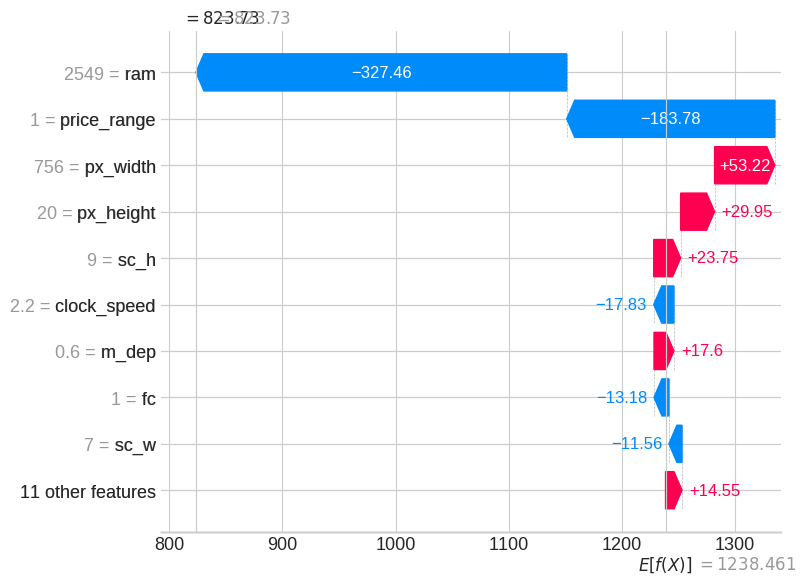

In [57]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values
model = xgboost.XGBRegressor().fit(X, y)
explainer = shap.Explainer(model)
shap_values = explainer(X)

# visualize the first prediction's explanation
shap.waterfall_plot(shap.Explanation(feature_names=df.columns[1:],values=shap_values[0]))


**Análise do Gráfico Waterfall SHAP (Previsão Individual):**

O gráfico waterfall acima explica a previsão de um exemplo individual do seu conjunto de dados.

*   **Base value (valor base):** Este é o valor médio de previsão do modelo para todo o conjunto de dados de treinamento. Ele representa o ponto de partida para a explicação.
*   **Setas coloridas (valores SHAP):** Cada seta colorida representa a contribuição de uma característica (feature) específica para desviar a previsão individual do valor base.
    *   As setas **vermelhas** indicam características que **aumentam** o valor da previsão (empurrando-o para a direita).
    *   As setas **azuis** indicam características que **diminuem** o valor da previsão (empurrando-o para a esquerda).
    *   O comprimento da seta indica a **magnitude** da contribuição da característica. Características com setas mais longas tiveram um impacto maior na previsão para este exemplo específico.
*   **f(x) (valor de saída do modelo):** Este é o valor de previsão final do modelo para o exemplo individual que está sendo explicado. Ele é a soma do valor base e de todas as contribuições SHAP das características.

**Interpretando o Gráfico Específico:**

Ao analisar o gráfico waterfall gerado, observe quais características têm as maiores contribuições (setas mais longas) e em qual direção (vermelho para aumentar, azul para diminuir) elas estão empurrando a previsão. Isso mostra quais características foram mais importantes para o modelo chegar à sua previsão para este exemplo particular.

**Interpretando o Gráfico Específico:**

Ao analisar o gráfico waterfall gerado, observe quais características têm as maiores contribuições (setas mais longas) e em qual direção (vermelho para aumentar, azul para diminuir) elas estão empurrando a previsão. Isso mostra quais características foram mais importantes para o modelo chegar à sua previsão para este exemplo particular.

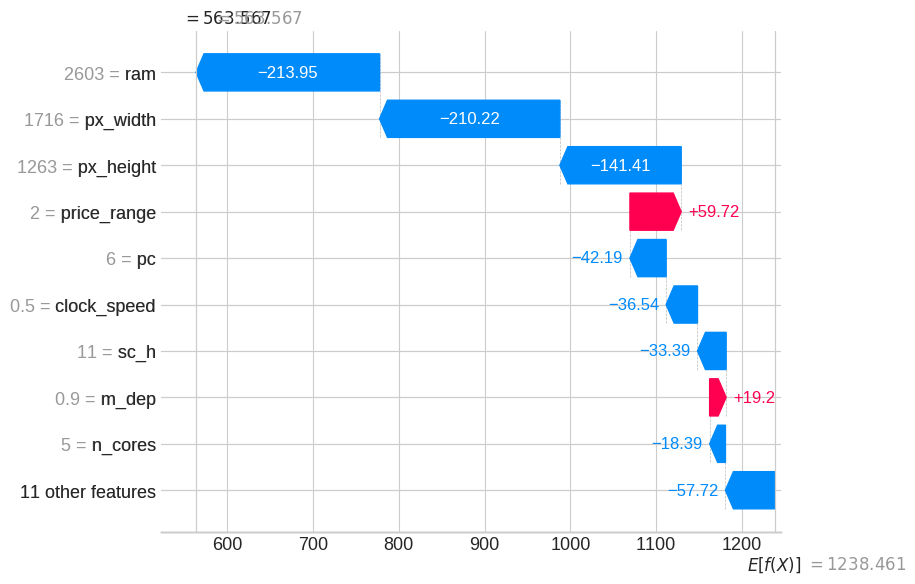

In [58]:
shap.waterfall_plot(shap.Explanation(feature_names=df.columns[1:],values=shap_values[2]))


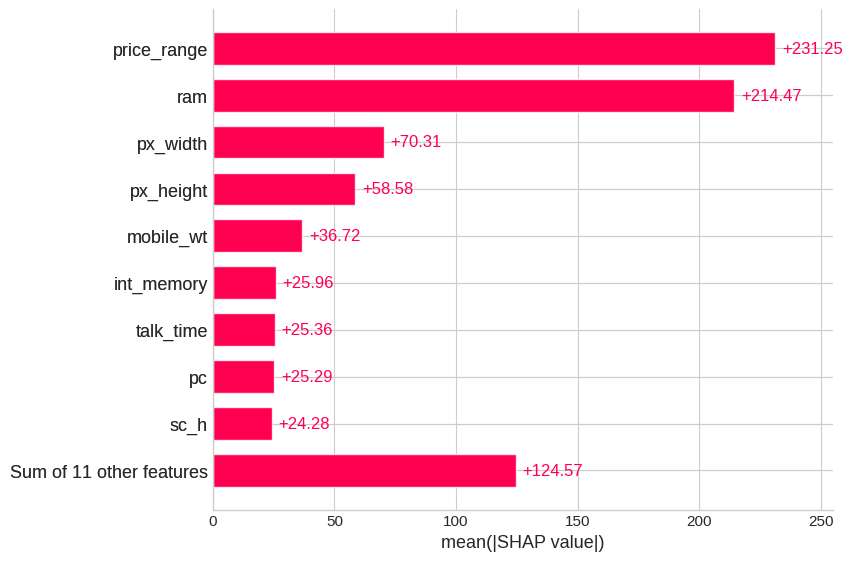

In [59]:
shap.plots.bar(shap.Explanation(feature_names=df.columns[1:],values=shap_values))


###Usando o MLFLOW

In [60]:
# Assumindo que os dados de teste (X_test_scaled, y_test) já foram carregados em células anteriores

# --- 1. Definir qual modelo carregar do MLflow Registry ---
# Vamos carregar a versão mais recente do nosso melhor modelo, o "Improved_SVC".
# O formato 'models:/<NomeDoModelo>/<Estágio_ou_Versao>' é o padrão do MLflow.
model_name = "Improved_SVC"
model_uri = f"models:/{model_name}/latest"

print(f"Carregando o modelo '{model_name}' (última versão) do MLflow Registry...")
print("-" * 60)

# --- 2. Carregar o modelo usando a URI ---
# mlflow.pyfunc é um formato genérico que garante que qualquer modelo
# (sklearn, pytorch, etc.) possa ser carregado e usado da mesma forma.
try:
    loaded_model = mlflow.pyfunc.load_model(model_uri)
    print("✅ Modelo carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo. Verifique se o nome '{model_name}' está correto no seu registro MLflow.")
    print(e)

# --- 3. Simular a chegada de "novos dados" ---
# Para simular um cenário real, vamos pegar as 5 primeiras amostras do nosso
# CONJUNTO DE TESTE, que o modelo nunca viu durante o treino ou validação.
novos_dados = X_test_scaled[:5]

# Vamos também pegar os rótulos verdadeiros para podermos comparar o resultado
valores_reais = y_test[:5]

# --- 4. Fazer previsões com o modelo carregado ---
if 'loaded_model' in locals():
    previsoes = loaded_model.predict(novos_dados)

    print("\n--- 🚀 Realizando previsões nos novos dados ---")

    # --- 5. Exibir os resultados de forma clara ---
    # Criamos um DataFrame do Pandas para comparar o valor real com a previsão do modelo.
    df_resultados = pd.DataFrame({
        "Valor Real (Gabarito)": valores_reais.values,
        "Previsão do Modelo": previsoes
    })

    # Usamos .to_string() para garantir uma formatação alinhada e limpa
    print(df_resultados.to_string())

Carregando o modelo 'Improved_SVC' (última versão) do MLflow Registry...
------------------------------------------------------------
✅ Modelo carregado com sucesso!

--- 🚀 Realizando previsões nos novos dados ---
   Valor Real (Gabarito)  Previsão do Modelo
0                      3                   3
1                      0                   0
2                      0                   0
3                      2                   2
4                      1                   1


##Teste de Inferência com o Modelo Carregado do MLflow
Esta célula demonstra a etapa final do ciclo de vida do modelo: o seu uso prático para fazer previsões.

O melhor modelo (Improved_SVC) é carregado diretamente do registro do MLflow, sem a necessidade de retreinamento. Para simular um cenário real, ele é usado para prever os resultados de um pequeno conjunto de dados que nunca viu antes (amostras do conjunto de teste).

A tabela de resultados exibe uma comparação direta:

Valor Real (Gabarito): A resposta correta.

Previsão do Modelo: A resposta que o modelo calculou de forma independente.

O resultado mostra que, para esta amostra, as previsões do modelo foram 100% corretas, correspondendo perfeitamente ao gabarito. Isso valida de forma prática a alta acurácia do modelo final e sua prontidão para ser utilizado em aplicações reais.

##Área de Testes

In [64]:
# --- CÉLULA DE TESTES INTERATIVOS ---

# Carregue o modelo (só precisa fazer uma vez)
model_uri = "models:/Improved_SVC/latest"
loaded_model = mlflow.pyfunc.load_model(model_uri)
print("✅ Modelo 'Improved_SVC' pronto para uso.")

# --- 🔬 ÁREA DE TESTES: MODIFIQUE OS NÚMEROS AQUI ---

# Teste: Altere estes dados para ver outras amostras de testes

# Teste 1 Ver as amostras da 10ª até a 15ª
indice_inicio = 10
indice_fim = 15

# Teste 2 (Exemplo alternativo): Ver apenas a amostra de número 99
# Lembre-se de usar [99:100] para manter o formato de tabela.
#indice_inicio = 99
#indice_fim = 100

# ---------------------------------------------------

# Seleciona os dados com base nos índices que você definiu
novos_dados_teste = X_test_scaled[indice_inicio:indice_fim]
valores_reais_teste = y_test[indice_inicio:indice_fim]

# Realiza as previsões
previsoes_teste = loaded_model.predict(novos_dados_teste)

# Exibe os resultados
print(f"\n--- Exibindo previsões para as amostras de {indice_inicio} a {indice_fim-1} ---")
df_teste = pd.DataFrame({
    "Índice da Amostra": range(indice_inicio, indice_fim),
    "Valor Real (Gabarito)": valores_reais_teste.values,
    "Previsão do Modelo": previsoes_teste
})
print(df_teste.to_string(index=False))

✅ Modelo 'Improved_SVC' pronto para uso.

--- Exibindo previsões para as amostras de 10 a 14 ---
 Índice da Amostra  Valor Real (Gabarito)  Previsão do Modelo
                10                      0                   0
                11                      2                   2
                12                      2                   1
                13                      1                   1
                14                      1                   1
